# Solving an MIS problem with QUBO Solver 

The goal of the tutorial is to show how to solve a **Maximum Independent Set (MIS) problem using QUBO Solver**.


## Mapping MIS to QUBO

Each node $i$ in the graph is assigned a binary variable $x_i \in \{0, 1\}$, where **$x_i = 1$ means node $i$ is selected** as part of the independent set.

The MIS problem is then written as the following QUBO minimization:

$$\min_x \; -\sum_i x_i + P \sum_{(i,j) \in E} x_i x_j$$

The objective has two competing terms:

- **$-\sum_i x_i$** — minimizing this encourages selecting *as many nodes as possible*, since each selected node decreases the objective.
- **$P \sum_{(i,j) \in E} x_i x_j$** — for every edge $(i,j)$, if *both* endpoints are selected ($x_i = 1$ and $x_j = 1$), this term adds a penalty $P$ to the objective, discouraging invalid selections.

$P$ is a penalty parameter that must be large enough to ensure that no two adjacent nodes are ever both selected in the optimal solution. The choice of $P$ can influence the quality of the results — too small and the penalty may be insufficient to rule out invalid solutions, too large and it may distort the energy landscape. It is therefore worth tuning $P$ depending on the structure of the graph.

## Why use the QUBO Solver to resolve an MIS problem? 

MIS maps cleanly to QUBO. The MIS problem can be reformulated as a Quadratic Unconstrained Binary Optimization (QUBO) problem: assign a binary variable to each node, maximize the number of selected nodes, and penalize any pair of connected nodes that are both selected. This yields a QUBO matrix that the library consumes directly.

## Mapping MIS to QUBO

Each node $i$ in the graph is assigned a binary variable $x_i \in \{0, 1\}$, where **$x_i = 1$ means node $i$ is selected** as part of the independent set.

The MIS problem is then written as the following QUBO minimization:

$$\min_x \; -\sum_i x_i + P \sum_{(i,j) \in E} x_i x_j$$

The objective has two competing terms:

- **$-\sum_i x_i$** — minimizing this encourages selecting *as many nodes as possible*, since each selected node decreases the objective.
- **$P \sum_{(i,j) \in E} x_i x_j$** — for every edge $(i,j)$, if *both* endpoints are selected ($x_i = 1$ and $x_j = 1$), this term adds a penalty $P$ to the objective, discouraging invalid selections.

$P$ is a penalty parameter that must be large enough to ensure that no two adjacent nodes are ever both selected in the optimal solution. The choice of $P$ can influence the quality of the results — too small and the penalty may be insufficient to rule out invalid solutions, too large and it may distort the energy landscape. It is therefore worth tuning $P$ depending on the structure of the graph.

Once this mapping has be done, the solver finds the assignment of $x_i$ values that maximises the number of selected nodes while avoiding any pair of connected nodes — which is exactly the MIS problem.

## Practical example

### Step 1: Define your graph

For the sake of this tutorial, we will use a simple `networkx` **Unit Disk Graph with 6 nodes** as input, as it is easy to understand and visualize. 

Nodes : [0, 1, 2, 3, 4, 5]
Edges : [(0, 1), (0, 2), (1, 3), (2, 3), (3, 4), (3, 5)]


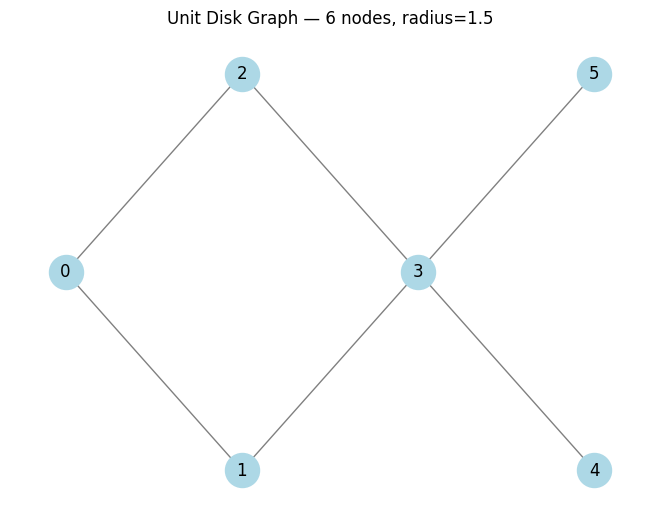

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Node positions in 2D space
pos = {
    0: (0.0, 1.0),
    1: (1.0, 0.0),
    2: (1.0, 2.0),
    3: (2.0, 1.0),
    4: (3.0, 0.0),
    5: (3.0, 2.0),
}

# Build Unit Disk Graph: connect nodes within distance threshold
radius = 1.5
G = nx.Graph()
G.add_nodes_from(pos.keys())
for i in pos:
    for j in pos:
        if i < j:
            dist = np.linalg.norm(np.array(pos[i]) - np.array(pos[j]))
            if dist <= radius:
                G.add_edge(i, j)

print(f"Nodes : {list(G.nodes())}")
print(f"Edges : {list(G.edges())}")

nx.draw(G, pos=pos, with_labels=True, node_color="lightblue",
        node_size=600, font_size=12, edge_color="gray")
plt.title(f"Unit Disk Graph — 6 nodes, radius={radius}")
plt.show()

In [2]:
import torch

from qubosolver import QUBOInstance
from qubosolver.config import SolverConfig
from qubosolver.solver import QuboSolver


# define QUBO
Q = torch.tensor([
    [-4.0, 1.0, 2.0, 1.5, 2.3, 0.9, 1.8, 2.7, 1.2],
    [ 1.0,-3.2, 1.7, 2.1, 0.8, 1.9, 2.2, 1.1, 1.6],
    [ 2.0, 1.7,-5.1, 0.7, 2.5, 1.3, 2.6, 1.4, 2.0],
    [ 1.5, 2.1, 0.7,-2.7, 1.2, 2.4, 0.6, 1.8, 2.1],
    [ 2.3, 0.8, 2.5, 1.2,-6.3, 1.0, 1.7, 2.8, 1.5],
    [ 0.9, 1.9, 1.3, 2.4, 1.0,-4.5, 2.3, 1.6, 0.9],
    [ 1.8, 2.2, 2.6, 0.6, 1.7, 2.3,-3.8, 1.2, 2.2],
    [ 2.7, 1.1, 1.4, 1.8, 2.8, 1.6, 1.2,-5.9, 1.4],
    [ 1.2, 1.6, 2.0, 2.1, 1.5, 0.9, 2.2, 1.4,-2.4],
], dtype=torch.float32)
instance = QUBOInstance(coefficients=Q)

# Create a SolverConfig object to use a quantum backend
config = SolverConfig(use_quantum=True)

# Instantiate the quantum solver.
solver = QuboSolver(instance, config)

# Solve the QUBO problem.
solution = solver.solve()

KeyboardInterrupt: 

In [ ]:
solution

QUBOSolution(bitstrings=tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=torch.int32), costs=tensor([82.1000]), counts=tensor([1000]), probabilities=tensor([1.]), solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)

In [ ]:
from qubosolver import QUBOInstance
from qubosolver.config import ClassicalConfig, SolverConfig
from qubosolver.solver import QuboSolverClassical, QuboSolverQuantum

# define QUBO
# Q = torch.tensor([[-1.0, 0.5, 1.2], [0.5, -2.0, 0.3], [1.2, 0.3, -3.0]])
Q = torch.tensor([
    [-4.0, 1.0, 2.0, 1.5, 2.3, 0.9, 1.8, 2.7, 1.2],
    [ 1.0,-3.2, 1.7, 2.1, 0.8, 1.9, 2.2, 1.1, 1.6],
    [ 2.0, 1.7,-5.1, 0.7, 2.5, 1.3, 2.6, 1.4, 2.0],
    [ 1.5, 2.1, 0.7,-2.7, 1.2, 2.4, 0.6, 1.8, 2.1],
    [ 2.3, 0.8, 2.5, 1.2,-6.3, 1.0, 1.7, 2.8, 1.5],
    [ 0.9, 1.9, 1.3, 2.4, 1.0,-4.5, 2.3, 1.6, 0.9],
    [ 1.8, 2.2, 2.6, 0.6, 1.7, 2.3,-3.8, 1.2, 2.2],
    [ 2.7, 1.1, 1.4, 1.8, 2.8, 1.6, 1.2,-5.9, 1.4],
    [ 1.2, 1.6, 2.0, 2.1, 1.5, 0.9, 2.2, 1.4,-2.4],
], dtype=torch.float32)
instance = QUBOInstance(coefficients=Q)

# Create a SolverConfig object with classical solver options.
classical_config = ClassicalConfig(
    classical_solver_type="cplex",
    cplex_maxtime=10.0,
    cplex_log_path="test_solver.log",
)
config = SolverConfig(use_quantum=False, classical=classical_config)

# Instantiate the classical solver via the pipeline's classical solver dispatcher.
classical_solver = QuboSolver(instance, config)

# Solve the QUBO problem.
solution = classical_solver.solve()

In [ ]:
solution

QUBOSolution(bitstrings=tensor([[0, 0, 0, 0, 1, 1, 0, 0, 0]], dtype=torch.int32), costs=tensor([-8.8000]), counts=None, probabilities=None, solution_status=<SolutionStatusType.UNPROCESSED: 'unprocessed'>)